In [59]:
#Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [60]:
# Step 2 — Load the CSV

df = pd.read_csv("sales_data.csv")

df.head()

,date,store_id,city,region,product_category,unit_price,discount_pct,promotion,is_holiday,marketing_spend,avg_temperature_c,competitor_price,units_sold,sales
0,2023-01-01,S01,Mumbai,West,Clothing,1784.06,0,0,0,3248.37,14.5,1761.64,31,55306.01
1,2023-01-01,S01,Mumbai,West,Electronics,15153.90,0,0,0,4315.29,15.4,16419.79,23,348539.74
2,2023-01-01,S01,Mumbai,West,Grocery,452.11,0,0,0,3567.67,20.0,NaN,35,15823.92
3,2023-01-01,S01,Mumbai,West,Home & Kitchen,2090.32,0,0,0,3648.54,17.7,2129.73,33,68980.48
4,2023-01-01,S02,Pune,West,Clothing,1864.00,0,0,0,5229.20,17.1,1703.19,27,50328.12


In [61]:
# Step 3 — Explore the Dataset
df.shape


(11696, 14)

In [62]:
df.columns

Index(['date', 'store_id', 'city', 'region', 'product_category', 'unit_price',
       'discount_pct', 'promotion', 'is_holiday', 'marketing_spend',
       'avg_temperature_c', 'competitor_price', 'units_sold', 'sales'],
      dtype='object')

In [63]:
df.dtypes

,0
date,object
store_id,object
city,object
region,object
product_category,object
unit_price,float64
discount_pct,int64
promotion,int64
is_holiday,int64
marketing_spend,float64


In [64]:
df.describe()

,unit_price,discount_pct,promotion,is_holiday,marketing_spend,avg_temperature_c,competitor_price,units_sold,sales
count,11696.000000,11696.000000,11696.000000,11696.000000,11557.000000,11580.000000,11508.000000,11696.000000,1.169600e+04
mean,4726.603274,2.717168,0.182114,0.016416,5171.752341,24.000648,4872.947331,35.948957,1.393245e+05
std,5748.226132,6.493977,0.385955,0.127074,1621.897922,5.986445,5908.126450,13.139715,1.654663e+05
min,315.750000,0.000000,0.000000,0.000000,500.000000,8.800000,369.050000,8.000000,6.970940e+03
25%,1040.945000,0.000000,0.000000,0.000000,4084.130000,18.700000,1559.322500,27.000000,3.183069e+04
50%,1867.490000,0.000000,0.000000,0.000000,5149.340000,24.000000,1987.725000,34.000000,6.379181e+04
75%,4412.440000,0.000000,0.000000,0.000000,6239.740000,29.300000,12855.790000,43.000000,1.293202e+05
max,16280.380000,25.000000,1.000000,1.000000,13003.520000,39.000000,18021.260000,116.000000,1.058387e+06


In [65]:
df.isnull().sum()

,0
date,0
store_id,0
city,0
region,0
product_category,0
unit_price,0
discount_pct,0
promotion,0
is_holiday,0
marketing_spend,139


In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
# Step 4 — Convert Date Column

df['date'] = pd.to_datetime(df['date'])

In [68]:
df['date'].dtype

dtype('<M8[ns]')

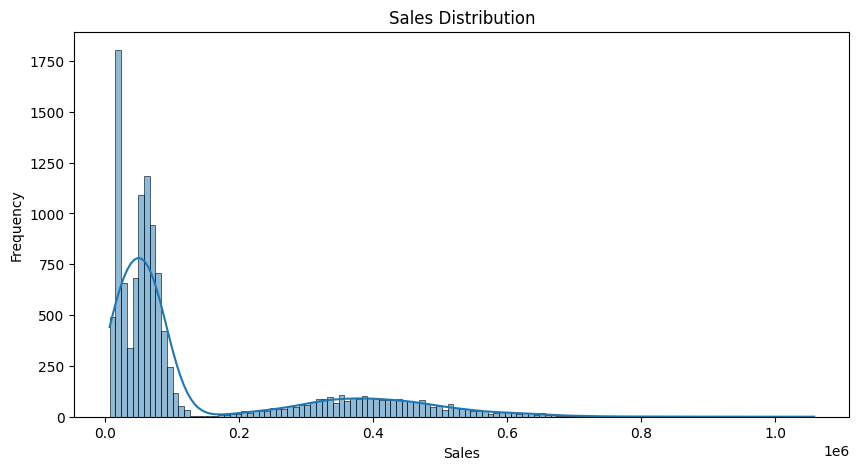

In [69]:
# Step 5 — Explore Sales

plt.figure(figsize=(10, 5))

sns.histplot(df['sales'], kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

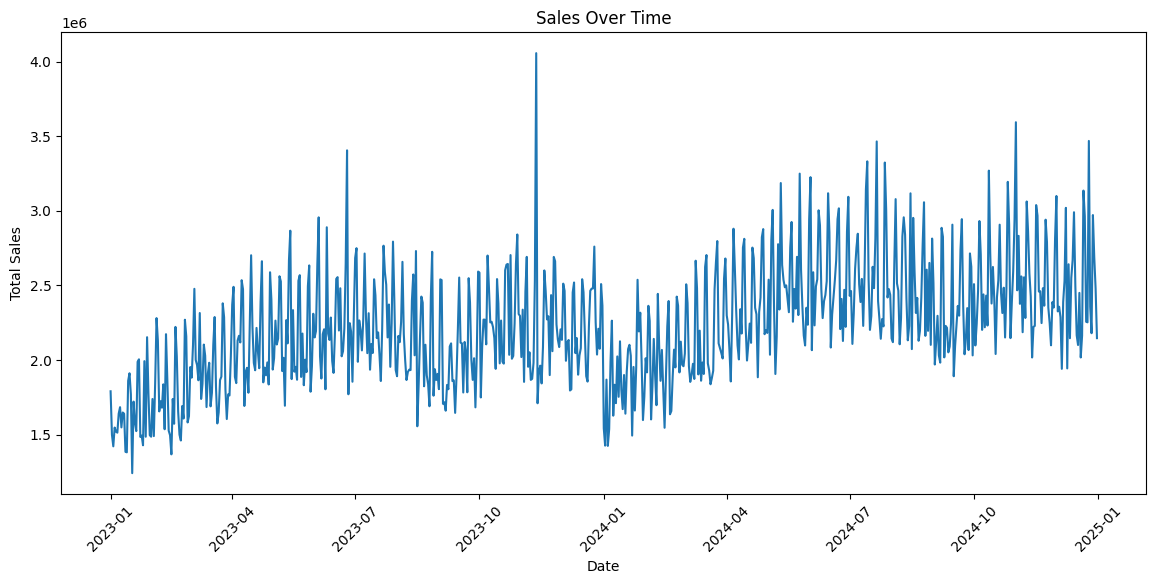

In [70]:
plt.figure(figsize=(14, 6))

daily_sales = df.groupby('date')['sales'].sum()

plt.plot(daily_sales)

plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [71]:
# Step 6 — Feature Engineering

df = df.sort_values(
    ['store_id', 'product_category', 'date']
).reset_index(drop=True)

In [72]:
# Step 7 — Create Date Features

df['year'] = df['date'].dt.year

df['month'] = df['date'].dt.month

df['day'] = df['date'].dt.day

df['day_of_week'] = df['date'].dt.dayofweek

df['quarter'] = df['date'].dt.quarter

In [73]:
df[
    [
        'date',
        'year',
        'month',
        'day',
        'day_of_week',
        'quarter'
    ]
].head()

,date,year,month,day,day_of_week,quarter
0,2023-01-01,2023,1,1,6,1
1,2023-01-02,2023,1,2,0,1
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,2,1
4,2023-01-05,2023,1,5,3,1


In [74]:
# Step 8 — Create Lag Features

group = df.groupby(
    ['store_id', 'product_category']
)['sales']

In [75]:
df['sales_lag_1'] = group.shift(1)
df['sales_lag_7'] = group.shift(7)

In [76]:
df[
    [
        'date',
        'store_id',
        'product_category',
        'sales',
        'sales_lag_1',
        'sales_lag_7'
    ]
].head(20)

,date,store_id,product_category,sales,sales_lag_1,sales_lag_7
0,2023-01-01,S01,Clothing,55306.01,NaN,NaN
1,2023-01-02,S01,Clothing,54582.37,55306.01,NaN
2,2023-01-03,S01,Clothing,47300.81,54582.37,NaN
3,2023-01-04,S01,Clothing,41800.76,47300.81,NaN
4,2023-01-05,S01,Clothing,44240.40,41800.76,NaN
5,2023-01-06,S01,Clothing,39516.21,44240.40,NaN
6,2023-01-07,S01,Clothing,64265.19,39516.21,NaN
7,2023-01-08,S01,Clothing,53928.33,64265.19,55306.01
8,2023-01-09,S01,Clothing,47221.73,53928.33,54582.37
9,2023-01-10,S01,Clothing,48686.35,47221.73,47300.81


In [77]:
# Step 9 — Rolling Average Features

df['sales_rolling_7'] = group.transform(
    lambda x: x.shift(1).rolling(
        window=7,
        min_periods=1
    ).mean()
)

In [78]:
df['sales_rolling_30'] = group.transform(
    lambda x: x.shift(1).rolling(
        window=30,
        min_periods=1
    ).mean()
)

In [79]:
df[
    [
        'date',
        'sales',
        'sales_lag_1',
        'sales_lag_7',
        'sales_rolling_7',
        'sales_rolling_30'
    ]
].head(20)

,date,sales,sales_lag_1,sales_lag_7,sales_rolling_7,sales_rolling_30
0,2023-01-01,55306.01,NaN,NaN,NaN,NaN
1,2023-01-02,54582.37,55306.01,NaN,55306.010000,55306.010000
2,2023-01-03,47300.81,54582.37,NaN,54944.190000,54944.190000
3,2023-01-04,41800.76,47300.81,NaN,52396.396667,52396.396667
4,2023-01-05,44240.40,41800.76,NaN,49747.487500,49747.487500
5,2023-01-06,39516.21,44240.40,NaN,48646.070000,48646.070000
6,2023-01-07,64265.19,39516.21,NaN,47124.426667,47124.426667
7,2023-01-08,53928.33,64265.19,55306.01,49573.107143,49573.107143
8,2023-01-09,47221.73,53928.33,54582.37,49376.295714,50117.510000
9,2023-01-10,48686.35,47221.73,47300.81,48324.775714,49795.756667


In [80]:
# Step 10 — Handle Missing Values

df.isnull().sum()

,0
date,0
store_id,0
city,0
region,0
product_category,0
unit_price,0
discount_pct,0
promotion,0
is_holiday,0
marketing_spend,139


In [81]:
df = df.dropna(
    subset=[
        'sales_lag_1',
        'sales_lag_7',
        'sales_rolling_7',
        'sales_rolling_30'
    ]
).copy()

In [82]:
df.shape

(11584, 23)

In [83]:
# Step 11 — Define X and y

X = df.drop(
    columns=['sales', 'date']
)

y = df['sales']

In [84]:
X.head()

,store_id,city,region,product_category,unit_price,discount_pct,promotion,is_holiday,marketing_spend,avg_temperature_c,...,units_sold,year,month,day,day_of_week,quarter,sales_lag_1,sales_lag_7,sales_rolling_7,sales_rolling_30
7,S01,Mumbai,West,Clothing,1739.62,0,0,0,4952.62,16.6,...,31,2023,1,8,6,1,64265.19,55306.01,49573.107143,49573.107143
8,S01,Mumbai,West,Clothing,1888.87,0,0,0,3268.78,16.3,...,25,2023,1,9,0,1,53928.33,54582.37,49376.295714,50117.510000
9,S01,Mumbai,West,Clothing,1803.20,0,0,0,7303.86,17.9,...,27,2023,1,10,1,1,47221.73,47300.81,48324.775714,49795.756667
10,S01,Mumbai,West,Clothing,1811.20,0,0,0,4451.10,15.7,...,25,2023,1,11,2,1,48686.35,41800.76,48522.710000,49684.816000
11,S01,Mumbai,West,Clothing,1437.68,15,1,0,4010.63,17.6,...,27,2023,1,12,3,1,45280.00,44240.40,49019.744286,49284.378182


In [85]:
# Step 12 — Identify Categorical and Numerical Columns

categorical_columns = X.select_dtypes(
    include=['object']
).columns.tolist()

numeric_columns = X.select_dtypes(
    exclude=['object']
).columns.tolist()

In [86]:
print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numeric_columns)

Categorical columns:
['store_id', 'city', 'region', 'product_category']

Numerical columns:
['unit_price', 'discount_pct', 'promotion', 'is_holiday', 'marketing_spend', 'avg_temperature_c', 'competitor_price', 'units_sold', 'year', 'month', 'day', 'day_of_week', 'quarter', 'sales_lag_1', 'sales_lag_7', 'sales_rolling_7', 'sales_rolling_30']


In [87]:
# Step 13 — Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [88]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (9267, 21)
Testing data: (2317, 21)


In [89]:
# Step 14 — Preprocessing Pipeline

numeric_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [90]:
categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'encoder',
            OneHotEncoder(handle_unknown='ignore')
        )
    ]
)

In [91]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            numeric_pipeline,
            numeric_columns
        ),
        (
            'categorical',
            categorical_pipeline,
            categorical_columns
        )
    ]
)

In [92]:
# Step 15 — Linear Regression Model

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [93]:
linear_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['unit_price', 'discount_pct',
                                                   'promotion', 'is_holiday',
                                                   'marketing_spend',
                                                   'avg_temperature_c',
                                                   'competitor_price',
                                                   'units_sold', 'year',
                                                   'month', 'day',
                                                   'day_of_week', 'quarter',
                                                   'sales_lag_1', 'sales_lag_7',
                                                   'sales_rolling_7',
                                                   'sales_rolling_30']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['store_id', 'city', 'region',
                                                   'product_category'])])),
                ('model', LinearRegression())])

In [94]:
linear_predictions = linear_model.predict(X_test)

In [95]:
# Step 16 — Evaluate Linear Regression

def evaluate_model(name, y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"\n{name}")
    print("-" * 40)
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAE  : {mae:,.2f}")
    print(f"R²   : {r2:.4f}")

    return rmse, mae, r2

In [96]:
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)


Linear Regression
----------------------------------------
RMSE : 41,955.96
MAE  : 25,244.38
R²   : 0.9380


In [97]:
# Step 17 — Random Forest Model

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        (
            'model',
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [98]:
random_forest_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['unit_price', 'discount_pct',
                                                   'promotion', 'is_holiday',
                                                   'marketing_spend',
                                                   'avg_temperature_c',
                                                   'competitor_price',
                                                   'units_sold', 'year',
                                                   'month', 'day',
                                                   'day_of_week', 'quarter',
                                                   'sales_lag_1', 'sales_lag_7',
                                                   'sales_rolling_7',
                                                   'sales_rolling_30']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['store_id', 'city', 'region',
                                                   'product_category'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [99]:
rf_predictions = random_forest_model.predict(
    X_test
)

In [100]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)


Random Forest
----------------------------------------
RMSE : 7,260.04
MAE  : 870.17
R²   : 0.9981


In [101]:
# Step 18 — Compare Both Models

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],

    'RMSE': [
        linear_results[0],
        rf_results[0]
    ],

    'MAE': [
        linear_results[1],
        rf_results[1]
    ],

    'R2': [
        linear_results[2],
        rf_results[2]
    ]
})

results

,Model,RMSE,MAE,R2
0,Linear Regression,41955.959461,25244.380240,0.937953
1,Random Forest,7260.044677,870.166986,0.998142


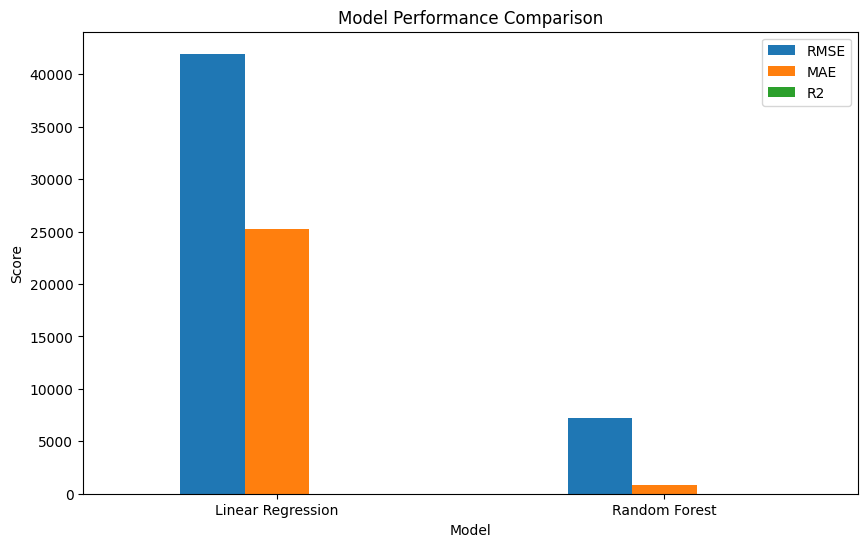

In [102]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

In [103]:
# Step 19 — Random Forest Feature Importance

preprocessor_fitted = (
    random_forest_model
    .named_steps['preprocessor']
)

In [104]:
rf_model = (
    random_forest_model
    .named_steps['model']
)

In [105]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [106]:
importance = rf_model.feature_importances_

In [107]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

In [108]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [109]:
feature_importance.head(20)

,Feature,Importance
15,numeric__sales_rolling_7,0.401066
29,categorical__product_category_Electronics,0.234386
7,numeric__units_sold,0.110777
0,numeric__unit_price,0.094037
14,numeric__sales_lag_7,0.073797
16,numeric__sales_rolling_30,0.067689
13,numeric__sales_lag_1,0.017442
1,numeric__discount_pct,0.000442
6,numeric__competitor_price,0.000103
4,numeric__marketing_spend,0.000052


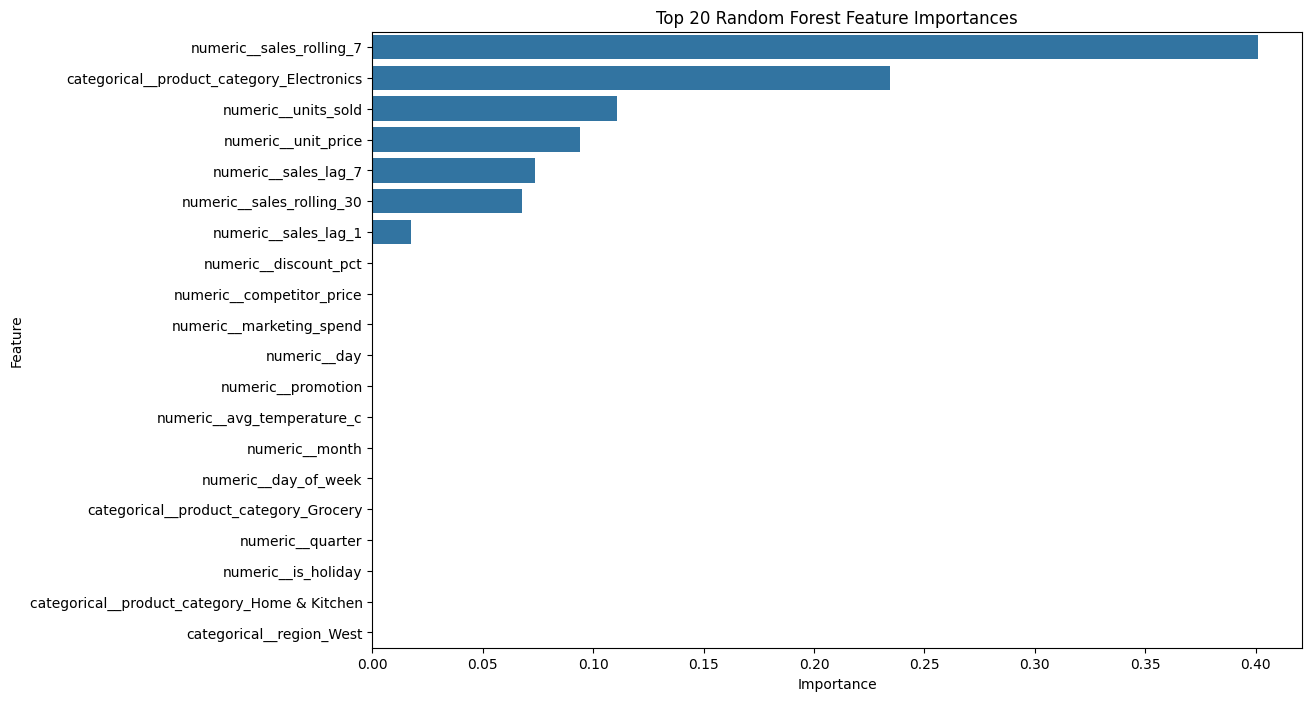

In [110]:
# Step 20 — Plot Feature Importance

plt.figure(figsize=(12, 8))

sns.barplot(
    data=feature_importance.head(20),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 20 Random Forest Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

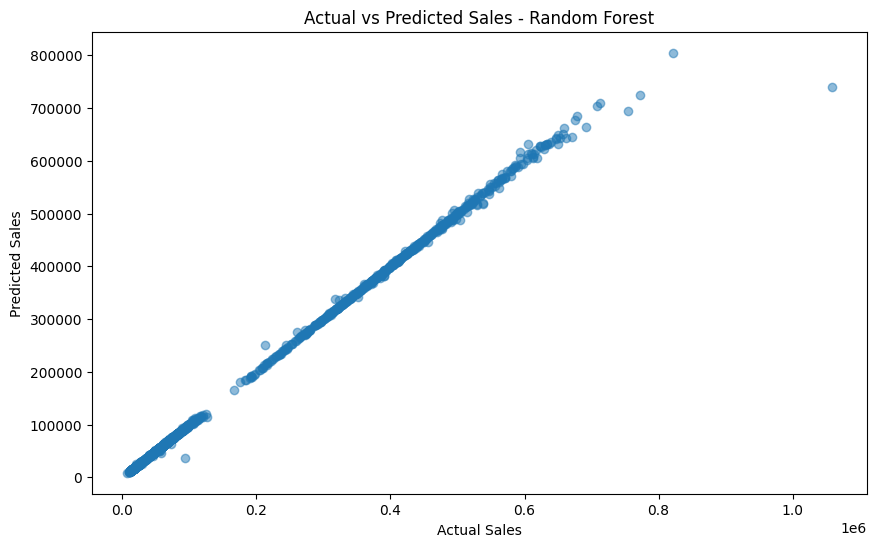

In [111]:
# Step 21 — Actual vs Predicted Sales

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales - Random Forest"
)

plt.show()

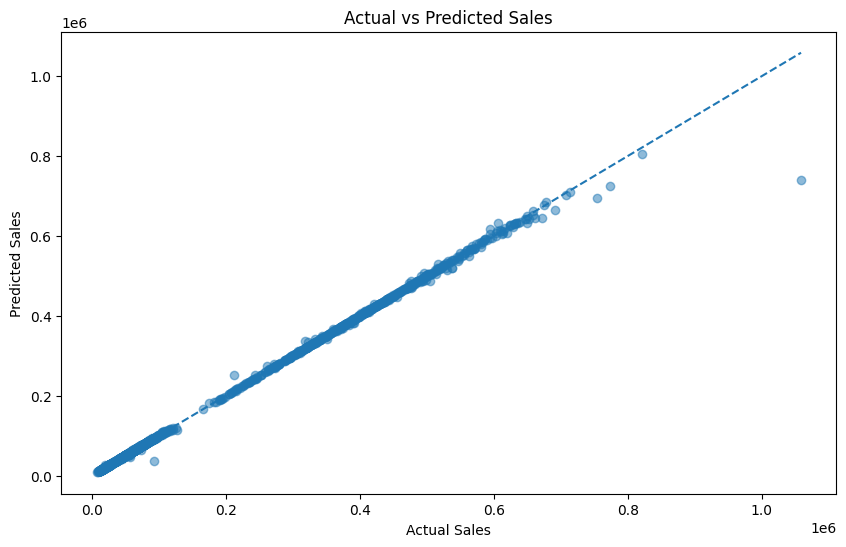

In [112]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    rf_predictions.min()
)

max_value = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()

In [113]:
# Step 22 — Hyperparameter Tuning

param_grid = {
    'model__n_estimators': [
        100,
        200,
        300
    ],

    'model__max_depth': [
        None,
        10,
        20
    ],

    'model__min_samples_split': [
        2,
        5
    ],

    'model__min_samples_leaf': [
        1,
        2
    ]
}

In [114]:
grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

In [115]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['unit_price',
                                                                          'discount_pct',
                                                                          'promotion',
                                                                          'is_holiday',
                                                                          'marketing_spend',
                                                                          'avg_temperature_c',
                                                                          'competitor_price',
                                                                          'units_sold',
                                                                          'year',
                                                                          'month',
                                                                          'day',
                                                                          'day_of_wee...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['store_id',
                                                                          'city',
                                                                          'region',
                                                                          'product_category'])])),
                                       ('model',
                                        RandomForestRegressor(n_estimators=200,
                                                              n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [116]:
# Step 23 — Best Parameters

print("Best Parameters:")

print(
    grid_search.best_params_
)

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}


In [117]:
best_model = grid_search.best_estimator_

In [118]:
# Step 24 — Predictions From Tuned Model

best_predictions = best_model.predict(
    X_test
)

In [119]:
tuned_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    best_predictions
)


Tuned Random Forest
----------------------------------------
RMSE : 7,198.61
MAE  : 859.62
R²   : 0.9982


In [120]:
# Step 25 — Compare All Models

final_results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],

    'RMSE': [
        linear_results[0],
        rf_results[0],
        tuned_results[0]
    ],

    'MAE': [
        linear_results[1],
        rf_results[1],
        tuned_results[1]
    ],

    'R2': [
        linear_results[2],
        rf_results[2],
        tuned_results[2]
    ]
})

final_results

,Model,RMSE,MAE,R2
0,Linear Regression,41955.959461,25244.380240,0.937953
1,Random Forest,7260.044677,870.166986,0.998142
2,Tuned Random Forest,7198.614694,859.618065,0.998173


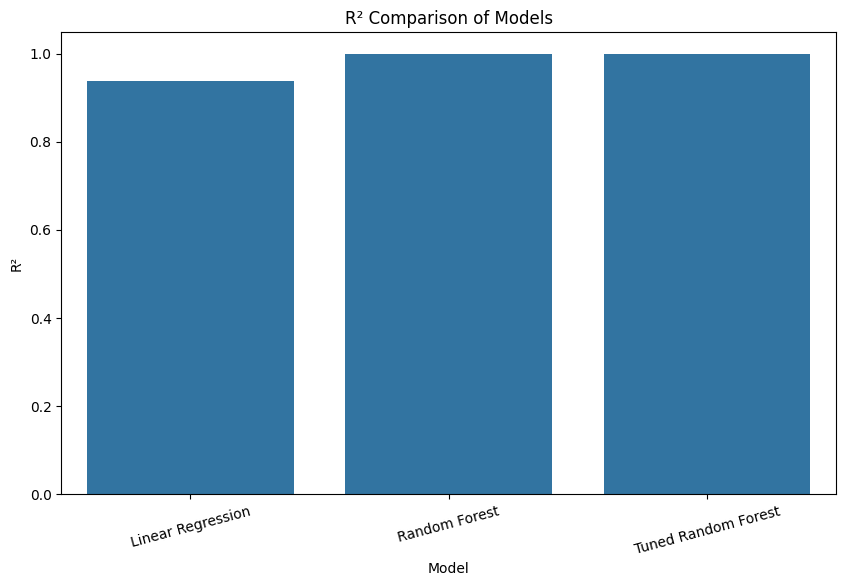

In [121]:
# Step 26 — Plot Final Model Performance

plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_results,
    x='Model',
    y='R2'
)

plt.title("R² Comparison of Models")

plt.xlabel("Model")
plt.ylabel("R²")

plt.xticks(rotation=15)

plt.show()

In [122]:
# Step 27 — Feature Importance of Tuned Model

best_preprocessor = (
    best_model
    .named_steps['preprocessor']
)

best_rf = (
    best_model
    .named_steps['model']
)

In [123]:
best_feature_names = (
    best_preprocessor
    .get_feature_names_out()
)

In [124]:
best_importance = best_rf.feature_importances_

In [125]:
best_feature_importance = pd.DataFrame({

    'Feature': best_feature_names,

    'Importance': best_importance

})

In [126]:
best_feature_importance = (
    best_feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

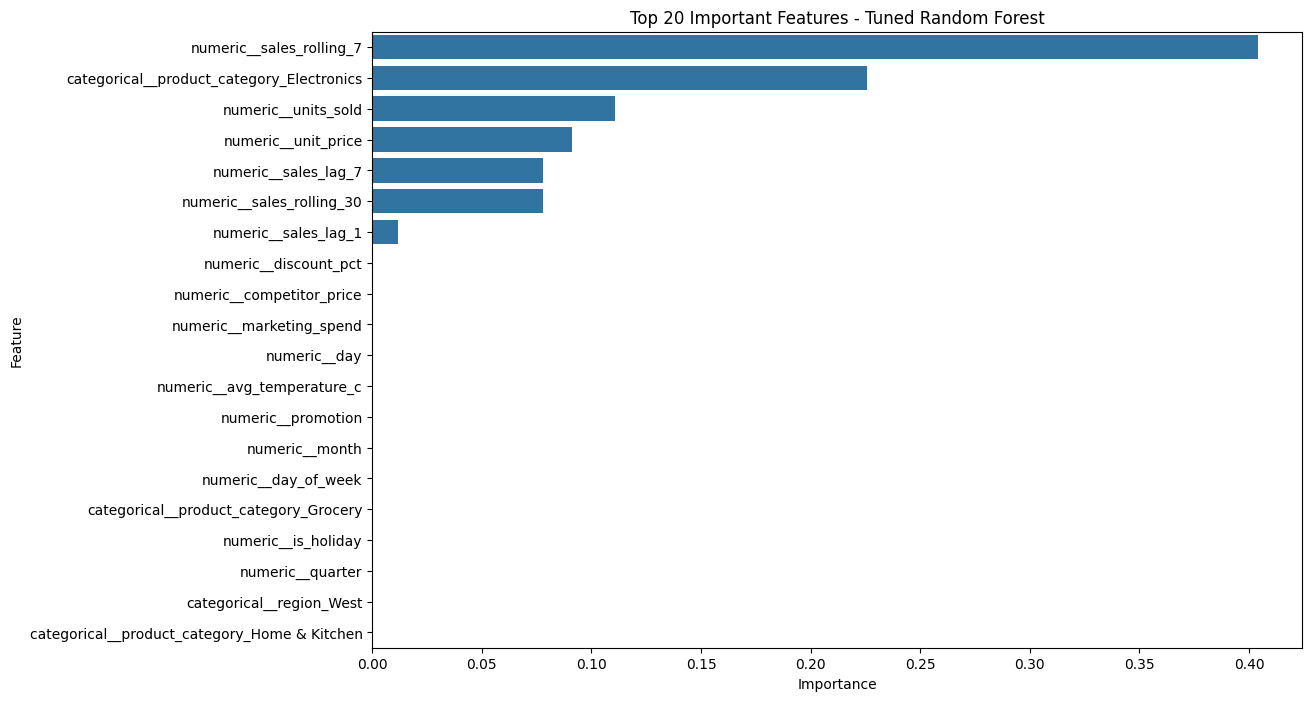

In [127]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=best_feature_importance.head(20),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 20 Important Features - Tuned Random Forest"
)

plt.show()

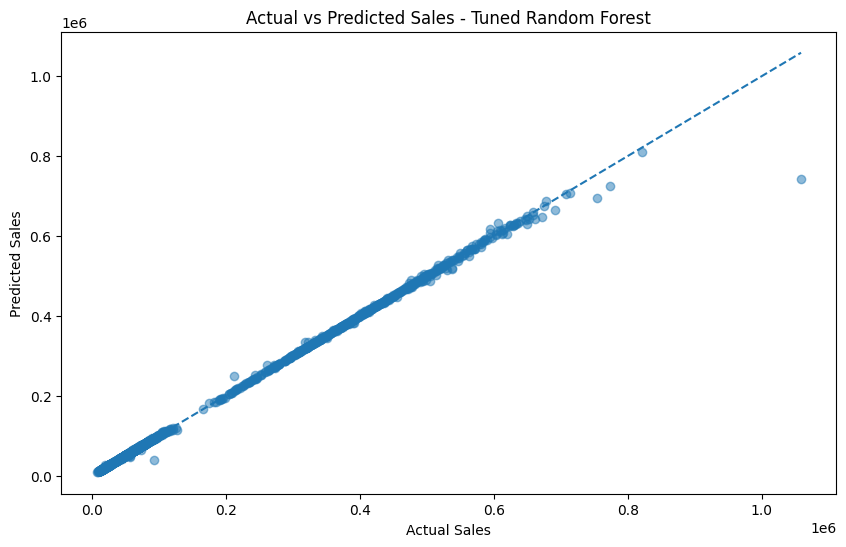

In [128]:
# Step 28 — Final Actual vs Predicted Plot

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales - Tuned Random Forest"
)

plt.show()